# 🎓 Student Performance Prediction
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1-b6Jf6io10mEnceh52oc64c1i2DpLHGD?usp=sharing)

> **Google Colab Notebook**: [https://colab.research.google.com/drive/1-b6Jf6io10mEnceh52oc64c1i2DpLHGD?usp=sharing](https://colab.research.google.com/drive/1-b6Jf6io10mEnceh52oc64c1i2DpLHGD?usp=sharing)


Saving Students Performance .csv to Students Performance  (11).csv


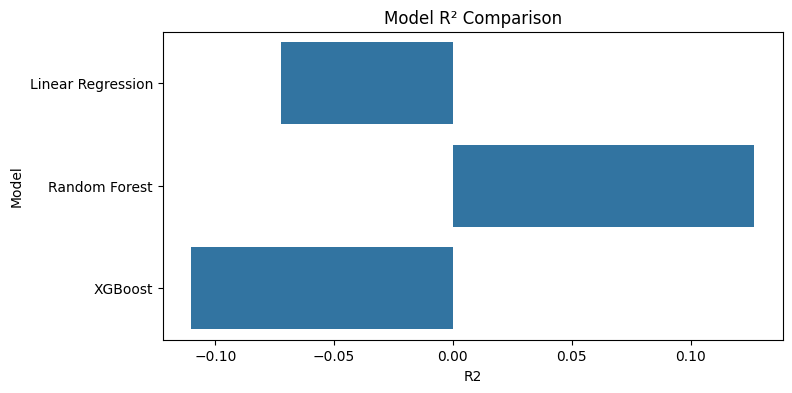

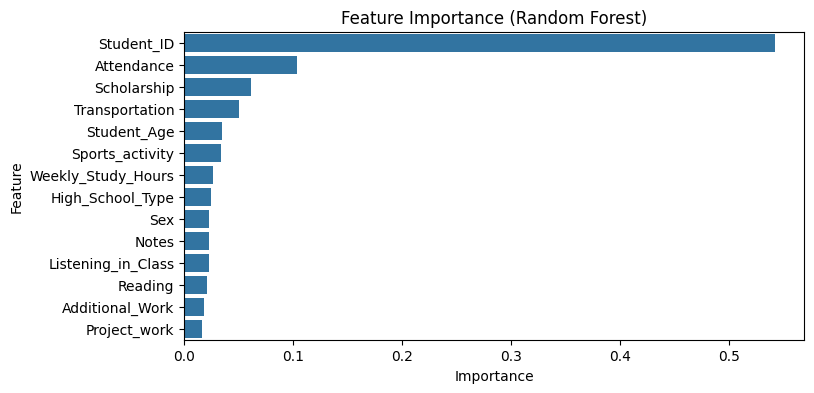

               Model        R2
0  Linear Regression -0.072443
1      Random Forest  0.126913
2            XGBoost -0.110290

Best Model: Random Forest

R2: 0.1269128216310509

MSE: 4.760972413793104


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from google.colab import files

uploaded = files.upload()
df = pd.read_csv(next(iter(uploaded.keys())))

target = "Grade"

df = df.dropna()
label_encoders = {}
for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


X = df.drop(target, axis=1)
y = df[target]

sc = StandardScaler()
X = sc.fit_transform(X)

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

models = {
    "Linear Regression":LinearRegression(),
    "Random Forest":RandomForestRegressor(),
    "XGBoost":XGBRegressor(eval_metric="rmse")
}

results = {}
preds = {}

for name,m in models.items():
    m.fit(X_train,y_train)
    p=m.predict(X_test)
    preds[name]=p
    results[name]=r2_score(y_test,p)

res = pd.DataFrame(results.items(),columns=["Model","R2"])

best = res.loc[res["R2"].idxmax(),"Model"]
best_model = models[best]
best_pred = preds[best]

plt.figure(figsize=(8,4))
sns.barplot(x="R2",y="Model",data=res)
plt.title("Model R² Comparison")
plt.show()

rf = RandomForestRegressor().fit(X_train,y_train)
importances = rf.feature_importances_
names = df.drop(target,axis=1).columns
imp = pd.DataFrame({"Feature":names,"Importance":importances}).sort_values(by="Importance",ascending=False)

plt.figure(figsize=(8,4))
sns.barplot(x="Importance",y="Feature",data=imp)
plt.title("Feature Importance (Random Forest)")
plt.show()

print(res)
print("\nBest Model:",best)
print("\nR2:",r2_score(y_test,best_pred))
print("\nMSE:",mean_squared_error(y_test,best_pred))

In [ ]:
import gradio as gr

def predict_grade(*args):
    feature_names = df.drop(target, axis=1).columns
    input_dict = {}

    for i, col_name in enumerate(feature_names):
        input_dict[col_name] = args[i]

    input_df_row = pd.DataFrame([input_dict])

    for col in feature_names:
        if col in label_encoders:
            input_df_row[col] = label_encoders[col].transform(input_df_row[col])

    scaled_input = sc.transform(input_df_row[feature_names])

    prediction = best_model.predict(scaled_input)

    return float(prediction[0])

gradio_inputs = []
input_feature_columns = df.drop(target, axis=1).columns

for col_name in input_feature_columns:
    if col_name in label_encoders:
        choices = label_encoders[col_name].classes_.tolist()
        gradio_inputs.append(gr.Dropdown(choices, label=col_name))
    elif col_name == 'Weekly_Study_Hours':
        gradio_inputs.append(gr.Number(label=col_name))
    else:
        gradio_inputs.append(gr.Textbox(label=col_name))

iface = gr.Interface(
    fn=predict_grade,
    inputs=gradio_inputs,
    outputs=gr.Number(label="Predicted Grade"),
    title="Student Performance Prediction",
    description="Predict a student's grade based on various factors."
)

iface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://f9fa8150399e6565a7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
